## Cell 1
Import libraries

In [23]:
# !pip install onnx
# !pip install onnxruntime
# !pip install onnxscript

In [24]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import openpyxl
import onnx
import onnxruntime as ort

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Cell 2
Load dataset

In [25]:
data_path = '/content/anomaly.xlsx' # Dataset path
df = pd.read_excel(data_path)

print(f"Shape: {df.shape}")
print("-" * 50)
print("Head:")
display(df.head())
print("-" * 50)
print("Info:")
df.info()
print("-" * 50)
print("Missing values:")
print(df.isnull().sum())
print("-" * 50)
print("State distribution:")
print(df['state'].value_counts(dropna=False))

Shape: (36000, 20)
--------------------------------------------------
Head:


,user_id,persona,day,window_idx,state,hour,unlock_count,notification_total,loan_app_open,unique_loan_apps,otp_received,aggressive_notification,app_switch,avg_session_duration_sec,financial_ratio,loan_velocity,otp_velocity,stress_proxy,behavior_score,is_train
0,U001,Heavy,1,0,Normal,0,2,5,0,0,0,-1,6,147,0.025,0.000,0.0,0,0.600,1
1,U001,Heavy,1,1,Normal,1,4,6,1,1,0,-1,5,90,0.133,0.017,0.0,19,1.012,1
2,U001,Heavy,1,2,Normal,2,7,7,0,0,0,-1,5,138,0.017,0.000,0.0,10,1.000,1
3,U001,Heavy,1,3,Normal,3,4,7,0,0,0,-1,4,80,0.025,0.000,0.0,3,0.617,1
4,U001,Heavy,1,4,Normal,4,2,9,0,0,0,-1,3,158,0.040,0.000,0.0,0,0.300,1


--------------------------------------------------
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   36000 non-null  object 
 1   persona                   36000 non-null  object 
 2   day                       36000 non-null  int64  
 3   window_idx                36000 non-null  int64  
 4   state                     36000 non-null  object 
 5   hour                      36000 non-null  int64  
 6   unlock_count              36000 non-null  int64  
 7   notification_total        36000 non-null  int64  
 8   loan_app_open             36000 non-null  int64  
 9   unique_loan_apps          36000 non-null  int64  
 10  otp_received              36000 non-null  int64  
 11  aggressive_notification   36000 non-null  int64  
 12  app_switch                36000 non-null  int64  
 13  avg_

## Cell 3
Feature Selection

In [26]:
features = [
    'unlock_count',
    'notification_total',
    'loan_app_open',
    'unique_loan_apps',
    'otp_received',
    'aggressive_notification',
    'app_switch',
    'avg_session_duration_sec',
    'financial_ratio',
    'loan_velocity',
    'otp_velocity',
    'hour'
]

# Excluded columns: user_id, persona, day, window_idx, state, stress_proxy, behavior_score, is_train
#
# Reason for exclusion:
# - user_id, persona, day, window_idx: Identifying and temporal indexing columns, they don't represent the user's behavioral features.
# - state, stress_proxy, behavior_score: Target labels or proxies for labels. This is an unsupervised learning task (Autoencoder) so we do not use labels during training.
# - is_train: Meta column used to define training split.

missing_features = [f for f in features if f not in df.columns]
if missing_features:
    print(f"Warning: Missing features in dataset: {missing_features}")

## Cell 4
Split dataset

In [27]:
from sklearn.model_selection import train_test_split

# Separate Normal and Anomaly data from the original DataFrame
normal_df = df[df['state'] == 'Normal'].copy()
anomaly_df = df[df['state'] != 'Normal'].copy()

# Split the Normal data into a training set for the autoencoder
# and a portion to be used in the test set for evaluation.
# Using 80% for autoencoder training and 20% for testing (as 'Normal' samples).
# The 'is_train' column is no longer directly used for this split but conceptually represents the origin.
train_df, normal_test_df = train_test_split(normal_df, test_size=0.2, random_state=42)

# Combine the normal samples reserved for testing with all the anomaly samples
# to create a comprehensive test set for classification evaluation.
test_df = pd.concat([normal_test_df, anomaly_df], ignore_index=True)

print(f"Number of training samples (Normal only): {len(train_df)}")
print(f"Number of normal samples in evaluation test set: {len(normal_test_df)}")
print(f"Number of anomaly samples in evaluation test set: {len(anomaly_df)}")
print(f"Total number of testing samples: {len(test_df)}")

print("\nTrain set state distribution:")
print(train_df['state'].value_counts())

print("\nTest set state distribution:")
print(test_df['state'].value_counts())

Number of training samples (Normal only): 21120
Number of normal samples in evaluation test set: 5280
Number of anomaly samples in evaluation test set: 9600
Total number of testing samples: 14880

Train set state distribution:
state
Normal    21120
Name: count, dtype: int64

Test set state distribution:
state
Normal      5280
Reminder    2400
Threat      2400
Panic       2400
Recovery    2400
Name: count, dtype: int64


## Cell 5
Normalize features

In [28]:
scaler = StandardScaler()

# Fit ONLY using training data
train_df[features] = scaler.fit_transform(train_df[features])

# Transform testing data using the fitted scaler
test_df[features] = scaler.transform(test_df[features])

import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Features normalized and scaler saved.")

Features normalized and scaler saved.


## Cell 6
Sequence Builder

Building sequences:   0%|          | 0/50 [00:00<?, ?it/s]

Building sequences:   0%|          | 0/50 [00:00<?, ?it/s]

X_train shape: (19970, 24, 12)
X_test shape: (13730, 24, 12)


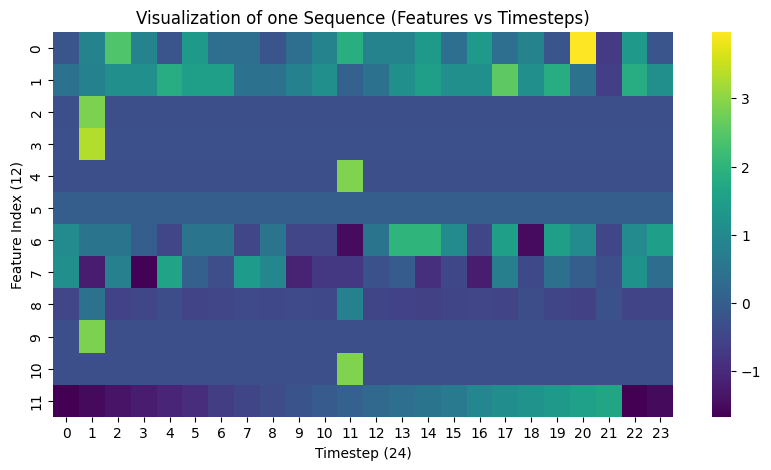

In [29]:
def create_sequences(dataframe, feature_cols, seq_length=24, stride=1):
    sequences = []
    labels = []

    grouped = dataframe.groupby('user_id')

    for user_id, group in tqdm(grouped, desc="Building sequences"):
        # Sort using day and window_idx
        group = group.sort_values(by=['day', 'window_idx'])

        feature_data = group[feature_cols].values
        state_data = group['state'].values if 'state' in group.columns else np.array(['Unknown'] * len(group))

        for i in range(0, len(group) - seq_length + 1, stride):
            seq = feature_data[i:i + seq_length]
            seq_label = state_data[i + seq_length - 1]

            sequences.append(seq)
            labels.append(seq_label)

    return np.array(sequences), np.array(labels)

seq_length = 24
stride = 1

X_train, y_train = create_sequences(train_df, features, seq_length, stride)
X_test, y_test = create_sequences(test_df, features, seq_length, stride)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

plt.figure(figsize=(10, 5))
sns.heatmap(X_train[0].T, cmap='viridis')
plt.title("Visualization of one Sequence (Features vs Timesteps)")
plt.xlabel("Timestep (24)")
plt.ylabel("Feature Index (12)")
plt.show()

## Cell 7
Create DataLoader

In [30]:
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences):
        # Transpose from (samples, seq_len, features) to (samples, channels, seq_len)
        self.sequences = torch.tensor(sequences, dtype=torch.float32).transpose(1, 2)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

batch_size = 64

train_dataset = TimeSeriesDataset(X_train)
test_dataset = TimeSeriesDataset(X_test)

# Shuffle training only
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 313
Test batches: 215


## Cell 8
Build Conv1D Autoencoder

In [31]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self):
        super(Conv1DAutoencoder, self).__init__()

        # Input shape: (batch, 12, 24)
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=12, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU()
            # Latent shape: (batch, 16, 24)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(in_channels=32, out_channels=12, kernel_size=3, padding=1)
            # Output shape: (batch, 12, 24)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

model = Conv1DAutoencoder().to(device)

print(model)

dummy_input = torch.randn(1, 12, 24).to(device)
print(f"Dummy output shape: {model(dummy_input).shape}")

Conv1DAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(12, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(32, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 12, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)
Dummy output shape: torch.Size([1, 12, 24])


## Cell 9
Training

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 100

val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_model_path = 'best_autoencoder.pth'

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in pbar:
        batch = batch.to(device)
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    epoch_train_loss = running_loss / len(train_dl)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_dl:
            batch = batch.to(device)
            outputs = model(batch)
            loss = criterion(outputs, batch)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_dl)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1} - Train Loss: {epoch_train_loss:.6f} - Val Loss: {epoch_val_loss:.6f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load(best_model_path))

Epoch 1/100:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 1 - Train Loss: 0.237863 - Val Loss: 0.055492


Epoch 2/100:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 2 - Train Loss: 0.034626 - Val Loss: 0.020448


Epoch 3/100:   0%|          | 0/281 [00:00<?, ?it/s]

...

Epoch 64/100:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 64 - Train Loss: 0.000210 - Val Loss: 0.000817


Epoch 65/100:   0%|          | 0/281 [00:00<?, ?it/s]

Epoch 65 - Train Loss: 0.000148 - Val Loss: 0.000165
Early stopping at epoch 65


<All keys matched successfully>

## Cell 10
Training Visualization

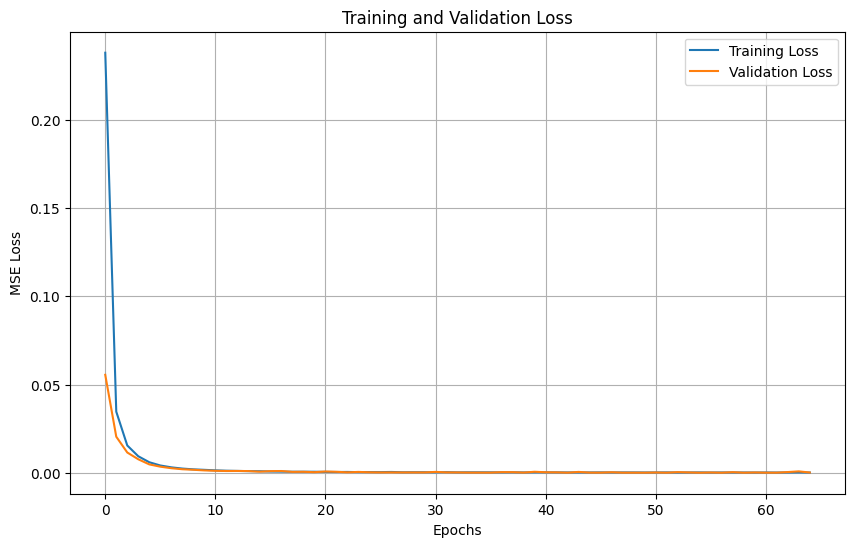

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

## Cell 11
Inference

In [34]:
model.eval()
reconstruction_errors = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference"):
        batch = batch.to(device)
        outputs = model(batch)
        # MSE per sequence (average across features and time)
        batch_errors = torch.mean((outputs - batch)**2, dim=[1, 2]).cpu().numpy()
        reconstruction_errors.extend(batch_errors)

reconstruction_errors = np.array(reconstruction_errors)

results_df = pd.DataFrame({
    'reconstruction_error': reconstruction_errors,
    'state': y_test
})

print(results_df.groupby('state')['reconstruction_error'].describe())

Inference:   0%|          | 0/215 [00:00<?, ?it/s]

           count      mean       std       min       25%       50%        75%  \
state                                                                           
Normal    4130.0  0.034668  0.068691  0.000009  0.000039  0.000098   0.028835   
Panic     2400.0  8.315091  2.691865  1.892509  6.358086  8.960679  10.317268   
Recovery  2400.0  2.638270  3.208169  0.114442  0.236414  0.355937   4.950324   
Reminder  2400.0  0.150488  0.069868  0.004927  0.100260  0.162616   0.199344   
Threat    2400.0  1.773520  0.718031  0.167548  1.267437  1.920488   2.309540   

                max  
state                
Normal     0.372273  
Panic     13.514893  
Recovery  12.997669  
Reminder   0.308275  
Threat     3.429165  


## Cell 12
Threshold Selection

In [35]:
# Evaluate thresholds based on normal data from validation set
model.eval()
normal_errors = []
with torch.no_grad():
    for batch in val_dl:
        batch = batch.to(device)
        outputs = model(batch)
        errors = torch.mean((outputs - batch)**2, dim=[1, 2]).cpu().numpy()
        normal_errors.extend(errors)

normal_errors = np.array(normal_errors)

threshold_95 = np.percentile(normal_errors, 95)
threshold_99 = np.percentile(normal_errors, 99)
threshold_mean_3std = np.mean(normal_errors) + 3 * np.std(normal_errors)

print(f"95 Percentile Threshold: {threshold_95:.6f}")
print(f"99 Percentile Threshold: {threshold_99:.6f}")
print(f"Mean + 3*Std Threshold: {threshold_mean_3std:.6f}")

recommended_threshold = threshold_mean_3std
print(f"Recommended Threshold (Mean + 3*Std): {recommended_threshold:.6f}")

95 Percentile Threshold: 0.000136
99 Percentile Threshold: 0.000336
Mean + 3*Std Threshold: 0.000367
Recommended Threshold (Mean + 3*Std): 0.000367


## Cell 13
Evaluation

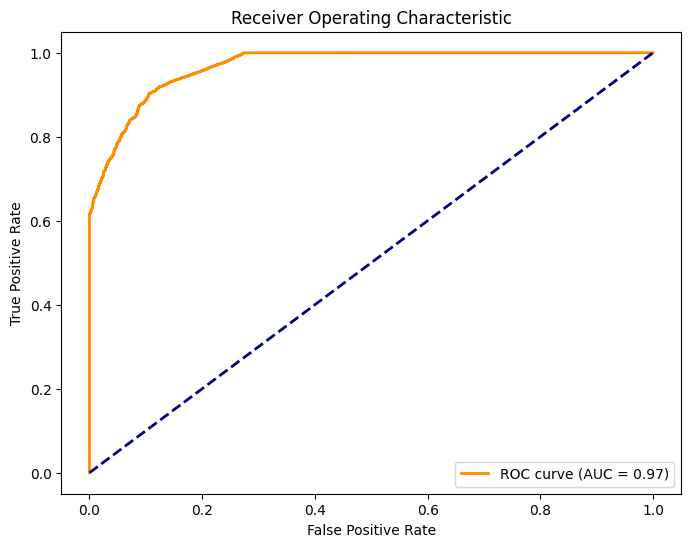

Precision: 0.8779
Recall: 1.0000
F1 Score: 0.9350


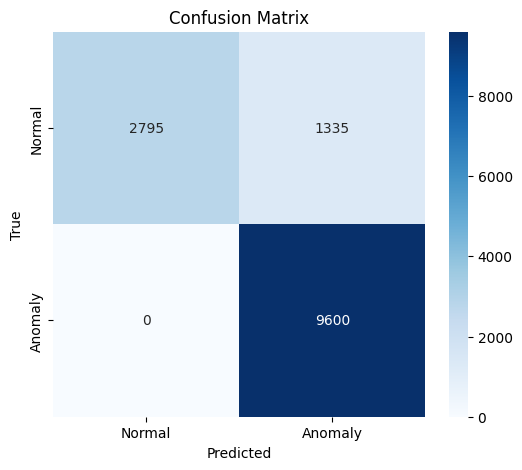

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.68      0.81      4130
     Anomaly       0.88      1.00      0.93      9600

    accuracy                           0.90     13730
   macro avg       0.94      0.84      0.87     13730
weighted avg       0.91      0.90      0.90     13730



In [36]:
# Binary labels: 0 for Normal, 1 for Anomaly
y_true_binary = (results_df['state'] != 'Normal').astype(int)
y_pred_binary = (results_df['reconstruction_error'] > recommended_threshold).astype(int)

fpr, tpr, _ = roc_curve(y_true_binary, results_df['reconstruction_error'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

precision, recall, f1, _ = precision_recall_fscore_support(y_true_binary, y_pred_binary, average='binary')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

cm = confusion_matrix(y_true_binary, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print("Classification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=['Normal', 'Anomaly']))

In [37]:
print('Value counts for y_true_binary:')
print(y_true_binary.value_counts())

Value counts for y_true_binary:
state
1    9600
0    4130
Name: count, dtype: int64


## Cell 14
Visualization

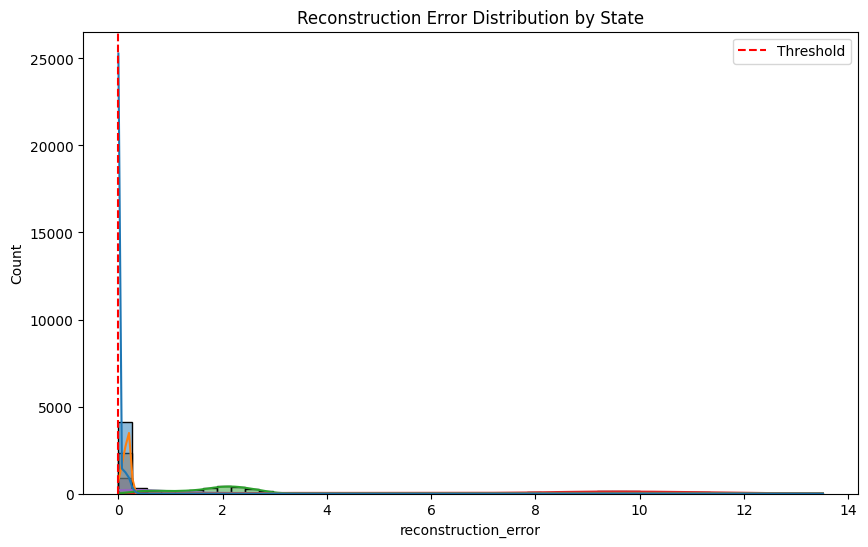

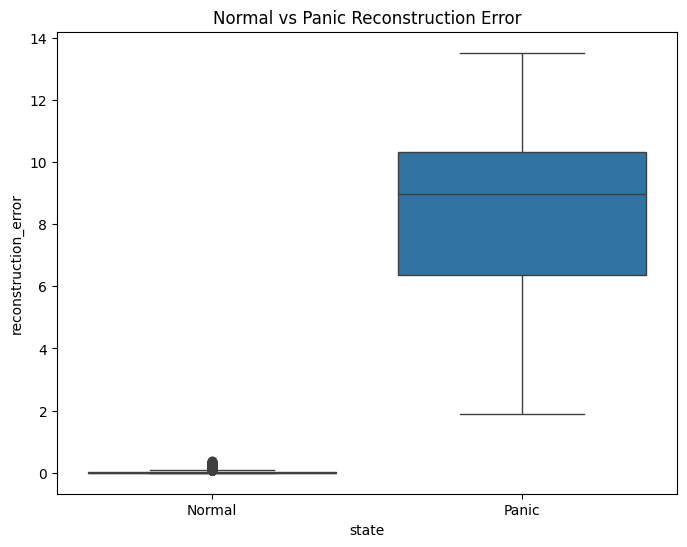

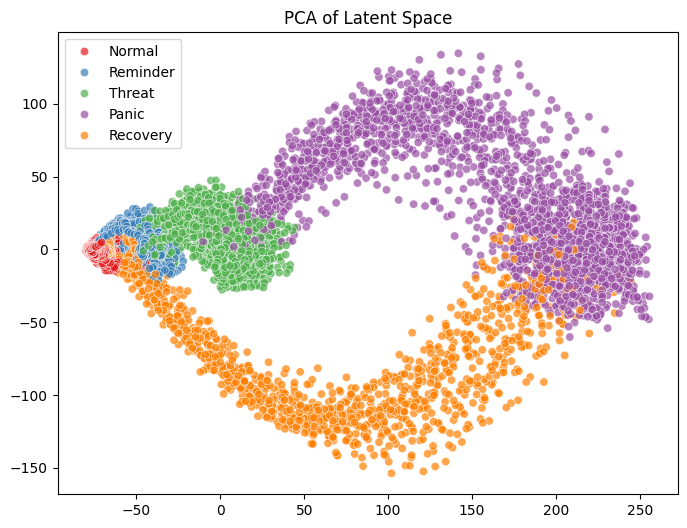

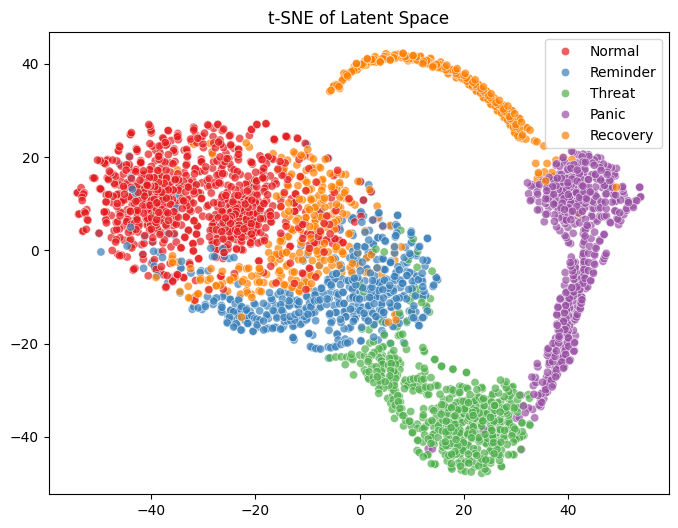

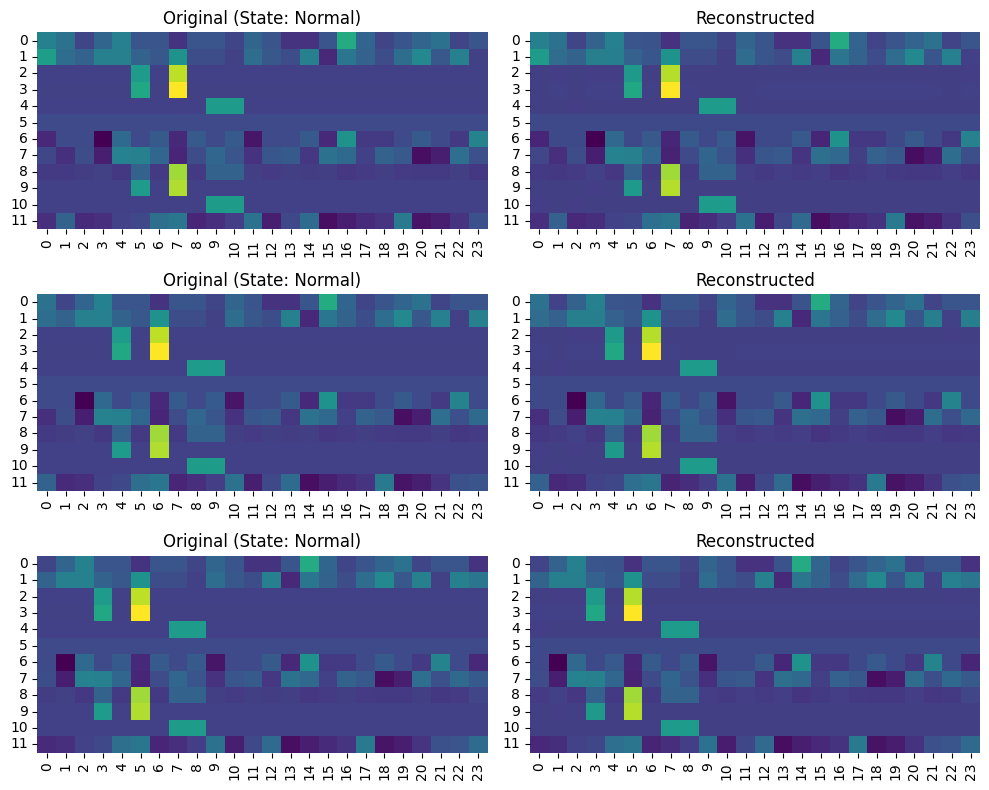

In [39]:
# Reconstruction Error Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x='reconstruction_error', hue='state', bins=50, kde=True)
plt.axvline(recommended_threshold, color='r', linestyle='dashed', label='Threshold')
plt.title('Reconstruction Error Distribution by State')
plt.legend()
plt.show()

# Normal vs Panic Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='state', y='reconstruction_error', data=results_df[results_df['state'].isin(['Normal', 'Panic'])])
plt.title('Normal vs Panic Reconstruction Error')
plt.show()

# Extract Latent Representations
latent_reprs = []
states_for_viz = []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        batch = batch.to(device)
        latent = model.encoder(batch)
        latent_flat = latent.view(latent.size(0), -1).cpu().numpy()
        latent_reprs.append(latent_flat)

        start = i * batch_size
        end = start + len(batch)
        states_for_viz.extend(y_test[start:end])

latent_reprs = np.concatenate(latent_reprs, axis=0)

# PCA
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_reprs)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=latent_pca[:, 0], y=latent_pca[:, 1], hue=states_for_viz, palette='Set1', alpha=0.7)
plt.title('PCA of Latent Space')
plt.show()

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
n_samples = min(len(latent_reprs), 3000)
latent_tsne = tsne.fit_transform(latent_reprs[:n_samples])
plt.figure(figsize=(8, 6))
sns.scatterplot(x=latent_tsne[:, 0], y=latent_tsne[:, 1], hue=states_for_viz[:n_samples], palette='Set1', alpha=0.7)
plt.title('t-SNE of Latent Space')
plt.show()

# Reconstructed Sequences Display
model.eval()
sample_inputs = test_dataset.sequences[:3].to(device)
with torch.no_grad():
    sample_outputs = model(sample_inputs)

sample_inputs = sample_inputs.cpu().numpy()
sample_outputs = sample_outputs.cpu().numpy()

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
for i in range(3):
    sns.heatmap(sample_inputs[i], ax=axes[i, 0], cmap='viridis', cbar=False)
    axes[i, 0].set_title(f'Original (State: {y_test[i]})')
    sns.heatmap(sample_outputs[i], ax=axes[i, 1], cmap='viridis', cbar=False)
    axes[i, 1].set_title('Reconstructed')
plt.tight_layout()
plt.show()

## Cell 15
Export

In [42]:
onnx_model_path = "conv1d_autoencoder.onnx"
model.to('cpu')
model.eval()

dummy_input = torch.randn(1, 12, 24)
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print(f"Exported to {onnx_model_path}")

onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("ONNX model valid.")

ort_session = ort.InferenceSession(onnx_model_path)
def to_numpy(t): return t.detach().cpu().numpy() if t.requires_grad else t.cpu().numpy()

torch_out = model(dummy_input)
ort_inputs = {ort_session.get_inputs()[0].name: to_numpy(dummy_input)}
ort_outs = ort_session.run(None, ort_inputs)
np.testing.assert_allclose(to_numpy(torch_out), ort_outs[0], rtol=1e-03, atol=1e-05)
print("PyTorch vs ONNX outputs match!")
model.to(device)

/tmp/ipykernel_2398/1720327560.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0716 20:30:25.524000 2398 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `Conv1DAutoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Conv1DAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported to conv1d_autoencoder.onnx
ONNX model valid.
PyTorch vs ONNX outputs match!


Conv1DAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(12, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(32, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 12, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)

## Cell 16
Final Summary

In [43]:
import time
model_size_mb = os.path.getsize(onnx_model_path) / (1024 * 1024)
total_params = sum(p.numel() for p in model.parameters())

dummy_input = torch.randn(1, 12, 24).to(device)
model.eval()
start_time = time.time()
with torch.no_grad():
    for _ in range(100):
        _ = model(dummy_input)
avg_inf_ms = ((time.time() - start_time) / 100) * 1000

android_mem_mb = model_size_mb * 4 + 10

print("="*40)
print("FINAL SUMMARY")
print("="*40)
print(f"Training Loss:    {train_losses[-1]:.6f}")
print(f"Validation Loss:  {best_val_loss:.6f}")
print(f"Threshold:        {recommended_threshold:.6f}")
print(f"ROC-AUC:          {roc_auc:.4f}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 Score:         {f1:.4f}")
print("-" * 40)
print(f"Model Size:       {model_size_mb:.4f} MB")
print(f"Total Parameters: {total_params}")
print(f"Inference Time:   {avg_inf_ms:.2f} ms")
print(f"Android Mem Use:  ~{android_mem_mb:.2f} MB")
print("="*40)

FINAL SUMMARY
Training Loss:    0.000148
Validation Loss:  0.000051
Threshold:        0.000367
ROC-AUC:          0.9687
Precision:        0.8779
Recall:           1.0000
F1 Score:         0.9350
----------------------------------------
Model Size:       0.0023 MB
Total Parameters: 5468
Inference Time:   0.32 ms
Android Mem Use:  ~10.01 MB
